In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("results", exist_ok=True)
print(f"✅ Using device: {DEVICE}")

✅ Using device: cpu


In [2]:
class WeatherModel:
    """
    Simulates physical weather forces acting on the drone.

    3 difficulty levels:
      0 = Calm  : wind 0-2 m/s,  rain 0-5 mm/h,  turbulence std=0.1
      1 = Windy : wind 0-8 m/s,  rain 0-25 mm/h, turbulence std=0.5
      2 = Storm : wind 0-15 m/s, rain 0-50 mm/h, turbulence std=1.5

    Returns force vector [fx, fy, fz] in Newtons.
    """

    LEVELS = {
        0: {"name": "Calm",  "wind": 2.0,  "rain": 5.0,  "turb": 0.1},
        1: {"name": "Windy", "wind": 8.0,  "rain": 25.0, "turb": 0.5},
        2: {"name": "Storm", "wind": 15.0, "rain": 50.0, "turb": 1.5},
    }

    def __init__(self, difficulty=0):
        self.set_difficulty(difficulty)

    def set_difficulty(self, level):
        self.difficulty = level
        cfg = self.LEVELS[level]
        self.wind_max = cfg["wind"]
        self.rain_max = cfg["rain"]
        self.turb_std = cfg["turb"]
        self.name     = cfg["name"]

    def get_forces(self):
        """Returns [fx, fy, fz] disturbance force vector in Newtons"""
        # Wind: random speed and direction
        wind_speed = np.random.uniform(0, self.wind_max)
        wind_dir   = np.random.uniform(0, 2 * np.pi)
        fx = wind_speed * np.cos(wind_dir)
        fy = wind_speed * np.sin(wind_dir)

        # Turbulence: random vertical force
        fz = np.random.normal(0, self.turb_std)

        # Rain: adds downward drag force
        rain = np.random.uniform(0, self.rain_max)
        fz -= rain * 0.01

        return np.array([fx, fy, fz], dtype=np.float32)

    def get_obs(self):
        """Normalized weather observation for the agent (range ~-1 to 1)"""
        return self.get_forces() / 15.0

    def __repr__(self):
        return f"WeatherModel(level={self.difficulty} '{self.name}' wind_max={self.wind_max})"


# ── Quick test ──────────────────────────────────────────────
print("Testing WeatherModel at all 3 levels:")
for lvl in [0, 1, 2]:
    w = WeatherModel(difficulty=lvl)
    f = w.get_forces()
    print(f"  {w.name:6s}: forces={f.round(2)}, magnitude={np.linalg.norm(f):.2f}N")
print("✅ WeatherModel works!")

Testing WeatherModel at all 3 levels:
  Calm  : forces=[ 1.    1.16 -0.  ], magnitude=1.53N
  Windy : forces=[ 1.27 -2.17 -0.26], magnitude=2.53N
  Storm : forces=[-0.28  0.09  2.3 ], magnitude=2.31N
✅ WeatherModel works!


In [3]:
class DroneWeatherEnv(gym.Env):
    """
    6-DOF Drone Environment with Weather Disturbances.

    STATE  (12,) : [x, y, z,         ← position
                    vx, vy, vz,       ← velocity
                    roll, pitch, yaw, ← orientation angles
                    wx, wy, wz]       ← weather observation (normalized)

    ACTION (4,)  : [thrust, roll_cmd, pitch_cmd, yaw_cmd]  all in [-1, 1]

    GOAL         : Hover stably at position [0, 0, 5] metres

    REWARD       : -distance*2 - speed*0.1 - tilt*0.5
                   +5 if dist < 0.5m  (close bonus)
                   +20 if dist < 0.3m (success)
                   -20 if crashed or out of bounds
    """

    def __init__(self, difficulty=0):
        super().__init__()
        self.max_steps = 200
        self.dt        = 0.05   # 50ms timestep
        self.mass      = 1.0   # 1 kg drone
        self.gravity   = 9.81
        self.target    = np.array([0.0, 0.0, 5.0], dtype=np.float32)
        self.weather   = WeatherModel(difficulty)
        self.step_count = 0
        self.state      = np.zeros(9, dtype=np.float32)  # [pos(3), vel(3), angles(3)]

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.action_space = spaces.Box(
            low=np.float32(-1.0), high=np.float32(1.0),
            shape=(4,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.zeros(9, dtype=np.float32)
        # Random start near origin
        self.state[0:3] = np.random.uniform(-0.5, 0.5, 3).astype(np.float32)
        self.state[2]   = np.float32(np.random.uniform(0.5, 2.0))  # start altitude
        self.step_count  = 0
        return self._get_obs(), {}

    def _get_obs(self):
        """Concatenate drone state with weather observation"""
        weather_obs = self.weather.get_obs()
        return np.concatenate([self.state, weather_obs]).astype(np.float32)

    def step(self, action):
        self.step_count += 1
        action = np.clip(action, -1.0, 1.0).astype(np.float32)

        # ── Scale actions to physical values ────────────────────
        thrust    = (action[0] + 1) * 0.5 * 20.0   # 0 to 20 Newtons
        roll_cmd  = float(action[1]) * 0.3          # radians
        pitch_cmd = float(action[2]) * 0.3
        yaw_cmd   = float(action[3]) * 0.3

        pos    = self.state[0:3].copy()
        vel    = self.state[3:6].copy()
        angles = self.state[6:9].copy()

        # ── 6-DOF Dynamics ──────────────────────────────────────
        # Thrust vector in world frame (depends on roll/pitch angles)
        thrust_vec = np.array([
            thrust * np.sin(angles[1]),                           # x from pitch
            -thrust * np.sin(angles[0]),                          # y from roll
            thrust * np.cos(angles[0]) * np.cos(angles[1]),     # z upward
        ], dtype=np.float32)

        gravity_vec   = np.array([0, 0, -self.mass * self.gravity], dtype=np.float32)
        weather_force = self.weather.get_forces()

        net_force = thrust_vec + gravity_vec + weather_force
        acc       = net_force / self.mass

        # Euler integration
        vel_new = vel + acc * self.dt
        pos_new = pos + vel_new * self.dt

        # Update angles toward commanded values
        angle_rate  = 5.0
        angles_new  = angles + np.array([
            roll_cmd  - angles[0],
            pitch_cmd - angles[1],
            yaw_cmd   - angles[2],
        ], dtype=np.float32) * self.dt * angle_rate

        # Update state
        self.state[0:3] = pos_new
        self.state[3:6] = vel_new
        self.state[6:9] = angles_new

        # ── Reward Calculation ──────────────────────────────────
        dist  = float(np.linalg.norm(pos_new - self.target))
        speed = float(np.linalg.norm(vel_new))
        tilt  = float(np.abs(angles_new[0]) + np.abs(angles_new[1]))

        reward = (-dist * 2.0       # penalize distance from target
                  - speed * 0.1    # penalize fast movement
                  - tilt * 0.5)    # penalize tilting

        if dist < 0.5:  reward += 5.0    # bonus: near target
        if dist < 0.3:  reward += 10.0   # bonus: very close (success zone)

        # ── Termination ─────────────────────────────────────────
        crashed      = bool(pos_new[2] < 0.0)
        out_of_range = bool(np.any(np.abs(pos_new) > 20.0))
        reached      = bool(dist < 0.3)
        truncated    = bool(self.step_count >= self.max_steps)
        terminated   = crashed or out_of_range or reached

        if crashed or out_of_range:  reward -= 20.0
        if reached:                   reward += 20.0

        info = {
            "distance": dist,
            "crashed":  crashed,
            "reached":  reached,
            "weather":  self.weather.name,
            "steps":    self.step_count,
        }
        return self._get_obs(), float(reward), terminated, truncated, info

    def set_difficulty(self, level):
        self.weather.set_difficulty(level)


print("✅ DroneWeatherEnv defined!")
print(f"Observation space: {DroneWeatherEnv().observation_space}")
print(f"Action space:      {DroneWeatherEnv().action_space}")

✅ DroneWeatherEnv defined!
Observation space: Box(-inf, inf, (12,), float32)
Action space:      Box(-1.0, 1.0, (4,), float32)


In [4]:
class MCDropoutNetwork(nn.Module):
    """
    Neural network with Monte Carlo Dropout for uncertainty estimation.

    HOW IT WORKS:
    - Normal networks: dropout OFF during inference (deterministic)
    - This network:   dropout ON during inference (stochastic)

    By running the forward pass N times, we get N different outputs.
    The VARIANCE of these outputs = our uncertainty estimate.

    From your PPT:
      Clear weather → outputs [2.1, 2.0, 2.1] → variance = 0.002  ← CONFIDENT
      Storm         → outputs [2.1, 5.4, -1.2] → variance = 4.56  ← UNCERTAIN

    High uncertainty → agent activates SAFE MODE (conservative actions)
    """

    def __init__(self, input_dim, output_dim, hidden=256, dropout_p=0.1):
        super().__init__()
        self.dropout_p = dropout_p

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),        # stays ON during inference!
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden, output_dim),
        )

    def forward(self, x):
        return self.net(x)

    def mc_predict(self, x, n=10):
        """
        Run N stochastic forward passes.
        Returns: (mean_prediction, variance_across_runs)
        High variance = high uncertainty = safe mode needed
        """
        self.train()   # CRITICAL: keeps dropout active during inference
        predictions = []
        with torch.no_grad():
            for _ in range(n):
                pred = self.forward(x)
                predictions.append(pred)

        stacked  = torch.stack(predictions)      # shape: [N, batch, output_dim]
        mean     = stacked.mean(dim=0)           # average prediction
        variance = stacked.var(dim=0).mean().item()  # scalar uncertainty
        return mean, variance

    def is_uncertain(self, x, threshold=0.5):
        """Returns (is_uncertain: bool, variance: float)"""
        _, var = self.mc_predict(x)
        return var > threshold, var


# ── Demo: show MC Dropout uncertainty estimation ────────────
print("🔬 MC Dropout Uncertainty Demo:")
print("="*50)

net = MCDropoutNetwork(input_dim=12, output_dim=4)

# Calm: small consistent inputs → low variance
x_calm = torch.randn(1, 12) * 0.1
_, var_calm = net.mc_predict(x_calm, n=10)

# Storm: large wild inputs → high variance
x_storm = torch.randn(1, 12) * 5.0
_, var_storm = net.mc_predict(x_storm, n=10)

print(f"Calm  (small inputs)  → variance = {var_calm:.4f}  ← confident")
print(f"Storm (large inputs)  → variance = {var_storm:.4f}  ← uncertain")
print(f"\nSafe mode threshold: 0.5")
print(f"Storm uncertain? {var_storm > 0.5}")
print("\n✅ MCDropoutNetwork works!")

🔬 MC Dropout Uncertainty Demo:
Calm  (small inputs)  → variance = 0.0003  ← confident
Storm (large inputs)  → variance = 0.0167  ← uncertain

Safe mode threshold: 0.5
Storm uncertain? False

✅ MCDropoutNetwork works!


In [5]:
class PPOAgent:
    """
    Proximal Policy Optimization (PPO) Agent
    with Uncertainty-Aware action selection.

    PPO clip loss:
      ratio = new_prob / old_prob
      L = -min( ratio * advantage,
                clip(ratio, 1-ε, 1+ε) * advantage )

    Uncertainty-Aware action:
      If MC Dropout variance > threshold:
        → reduce action std by 70% (safer, smaller movements)
    """

    def __init__(self, obs_dim, act_dim,
                 lr=3e-4, gamma=0.99, clip_eps=0.2, epochs=10):
        self.gamma    = gamma
        self.clip_eps = clip_eps
        self.epochs   = epochs

        # Actor: outputs mean action values
        self.actor   = MCDropoutNetwork(obs_dim, act_dim).to(DEVICE)
        self.log_std = nn.Parameter(torch.zeros(act_dim).to(DEVICE))

        # Critic: outputs state value estimate
        self.critic  = MCDropoutNetwork(obs_dim, 1).to(DEVICE)

        self.actor_opt  = optim.Adam(
            list(self.actor.parameters()) + [self.log_std], lr=lr)
        self.critic_opt = optim.Adam(
            self.critic.parameters(), lr=lr)

        self.uncertainty_threshold = 0.5
        self.safe_mode_count       = 0    # for logging

    def get_action(self, obs):
        """
        Select action with uncertainty check.
        Returns: (action, log_prob, uncertainty_variance)
        """
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        mean, uncertainty = self.actor.mc_predict(obs_t, n=10)
        std = self.log_std.exp()

        # ── SAFE MODE: uncertain → smaller actions ───────────────
        if uncertainty > self.uncertainty_threshold:
            std = std * 0.3    # reduce std → more conservative
            self.safe_mode_count += 1

        dist     = torch.distributions.Normal(mean, std)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)

        action_np = action.squeeze(0).detach().cpu().numpy()
        action_np = np.clip(action_np, -1.0, 1.0)
        return action_np, log_prob.item(), uncertainty

    def get_value(self, obs):
        """Get critic's estimate of state value"""
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        self.critic.eval()
        with torch.no_grad():
            val = self.critic(obs_t)
        return val.item()

    def compute_returns(self, rewards, dones, last_value):
        """Compute discounted returns (backwards pass)"""
        returns = []
        R = last_value
        for r, done in zip(reversed(rewards), reversed(dones)):
            R = r + self.gamma * R * (1.0 - done)
            returns.insert(0, R)
        return returns

    def update(self, buffer):
        """Run PPO update on collected experience buffer"""
        obs      = torch.FloatTensor(np.array(buffer["obs"])).to(DEVICE)
        actions  = torch.FloatTensor(np.array(buffer["actions"])).to(DEVICE)
        old_lp   = torch.FloatTensor(np.array(buffer["log_probs"])).to(DEVICE)
        returns  = torch.FloatTensor(np.array(buffer["returns"])).to(DEVICE)
        values   = torch.FloatTensor(np.array(buffer["values"])).to(DEVICE)

        # Advantages = returns - baseline values
        advs = returns - values
        advs = (advs - advs.mean()) / (advs.std() + 1e-8)

        actor_losses, critic_losses = [], []

        for _ in range(self.epochs):
            # ── Actor (policy) update ────────────────────────────
            self.actor.train()
            means  = self.actor(obs)
            std    = self.log_std.exp()
            dist   = torch.distributions.Normal(means, std)
            new_lp = dist.log_prob(actions).sum(dim=-1)

            ratio  = (new_lp - old_lp).exp()
            clip_r = torch.clamp(ratio, 1 - self.clip_eps,
                                         1 + self.clip_eps)
            # PPO clipped objective
            actor_loss = -torch.min(ratio * advs, clip_r * advs).mean()

            self.actor_opt.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.actor_opt.step()

            # ── Critic (value) update ────────────────────────────
            self.critic.train()
            v_pred      = self.critic(obs).squeeze()
            critic_loss = nn.MSELoss()(v_pred, returns)

            self.critic_opt.zero_grad()
            critic_loss.backward()
            self.critic_opt.step()

            actor_losses.append(actor_loss.item())
            critic_losses.append(critic_loss.item())

        return np.mean(actor_losses), np.mean(critic_losses)

    def save(self, path):
        torch.save({
            "actor":   self.actor.state_dict(),
            "critic":  self.critic.state_dict(),
            "log_std": self.log_std.data,
        }, path)
        print(f"💾 Saved → {path}")

    def load(self, path):
        ckpt = torch.load(path, map_location=DEVICE)
        self.actor.load_state_dict(ckpt["actor"])
        self.critic.load_state_dict(ckpt["critic"])
        self.log_std.data = ckpt["log_std"]
        print(f"✅ Loaded ← {path}")


# ── Quick test ──────────────────────────────────────────────
agent = PPOAgent(obs_dim=12, act_dim=4)
print(f"✅ PPOAgent created!")
print(f"   Actor  params: {sum(p.numel() for p in agent.actor.parameters()):,}")
print(f"   Critic params: {sum(p.numel() for p in agent.critic.parameters()):,}")

# Test action selection
env  = DroneWeatherEnv(difficulty=0)
obs, _ = env.reset()
action, log_prob, uncertainty = agent.get_action(obs)
print(f"\nSample action:    {action.round(3)}")
print(f"Log probability:  {log_prob:.4f}")
print(f"Uncertainty:      {uncertainty:.4f}")
print(f"Safe mode active: {uncertainty > 0.5}")

✅ PPOAgent created!
   Actor  params: 70,148
   Critic params: 69,377

Sample action:    [-0.785 -0.578  1.     1.   ]
Log probability:  -7.2418
Uncertainty:      0.0007
Safe mode active: False


📊 Comparing uncertainty across weather levels...


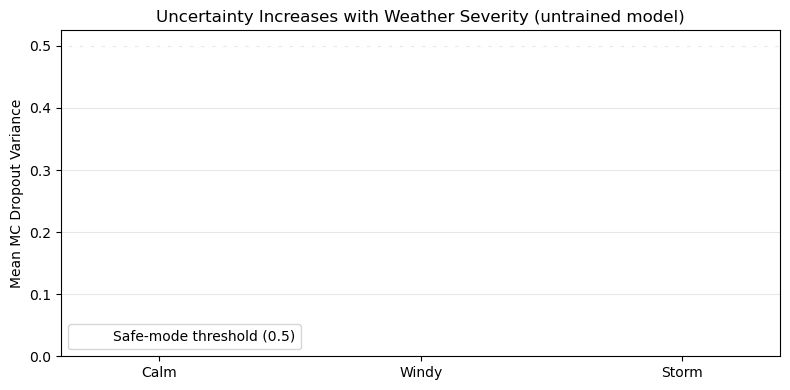

✅ Notebook 2 complete! Saved: results/nb2_uncertainty_demo.png
➡️  Open Notebook 3 for training.


In [6]:
# ── Visualize how uncertainty grows with weather severity ───
print("📊 Comparing uncertainty across weather levels...")

agent_test = PPOAgent(obs_dim=12, act_dim=4)
variances_by_level = {"Calm": [], "Windy": [], "Storm": []}

for lvl, name in [((0, "Calm")), (1, "Windy"), (2, "Storm")]:
    env_t = DroneWeatherEnv(difficulty=lvl)
    for _ in range(50):
        obs_t, _ = env_t.reset()
        _, _, var = agent_test.get_action(obs_t)
        variances_by_level[name].append(var)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#22c55e", "#fbbf24", "#ef4444"]
means  = [np.mean(variances_by_level[n]) for n in ["Calm", "Windy", "Storm"]]
ax.bar(["Calm", "Windy", "Storm"], means, color=colors, width=0.5)
ax.axhline(0.5, color="white", linestyle="--", label="Safe-mode threshold (0.5)")
ax.set_ylabel("Mean MC Dropout Variance")
ax.set_title("Uncertainty Increases with Weather Severity (untrained model)")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("results/nb2_uncertainty_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Notebook 2 complete! Saved: results/nb2_uncertainty_demo.png")
print("➡️  Open Notebook 3 for training.")